### Normalizing particle data to match normalized density profile

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit

import numpy as np
import sys

sys.path.append('../src/')
# from density_profiles import read_density_profile  # Removed: function not found here
import data_ios 
from data_ios import read_density_profile  # Correct import

In [3]:
density_filename = '../data/tng35-3-dark/halo_21537_density_profiles.hdf5'


In [4]:
halo_params = data_ios.read_halo_params("../data/tng35-3-dark/halo_21537_params.hdf5")
r200c = halo_params['R200c']
M200c = halo_params['M200c']
c200c = halo_params['c200c']
rho200c = halo_params['M200c']/(4/3. * np.pi * halo_params['R200c']**3)
snap = halo_params['snap']
rs = r200c / c200c

/tmp/ipykernel_727693/3815607487.py:9: RuntimeWarning: divide by zero encountered in log10
  ax[3].plot(np.log10(r/r200c[j]), np.log10(rho/rho200c[j]), color=cmap(norm(snap)), ls='-')
/tmp/ipykernel_727693/3815607487.py:10: RuntimeWarning: divide by zero encountered in log10
  ax[2].plot(np.log10(r/r200c[j]), np.log10(rho), color=cmap(norm(snap)), ls='-')
/tmp/ipykernel_727693/3815607487.py:11: RuntimeWarning: divide by zero encountered in log10
  ax[1].plot(np.log10(r/r200c[j]), np.log10(rho), color=cmap(norm(snap)), ls='-')
/tmp/ipykernel_727693/3815607487.py:12: RuntimeWarning: divide by zero encountered in log10
  ax[0].plot(np.log10(r), np.log10(rho), color=cmap(norm(snap)), ls='-')


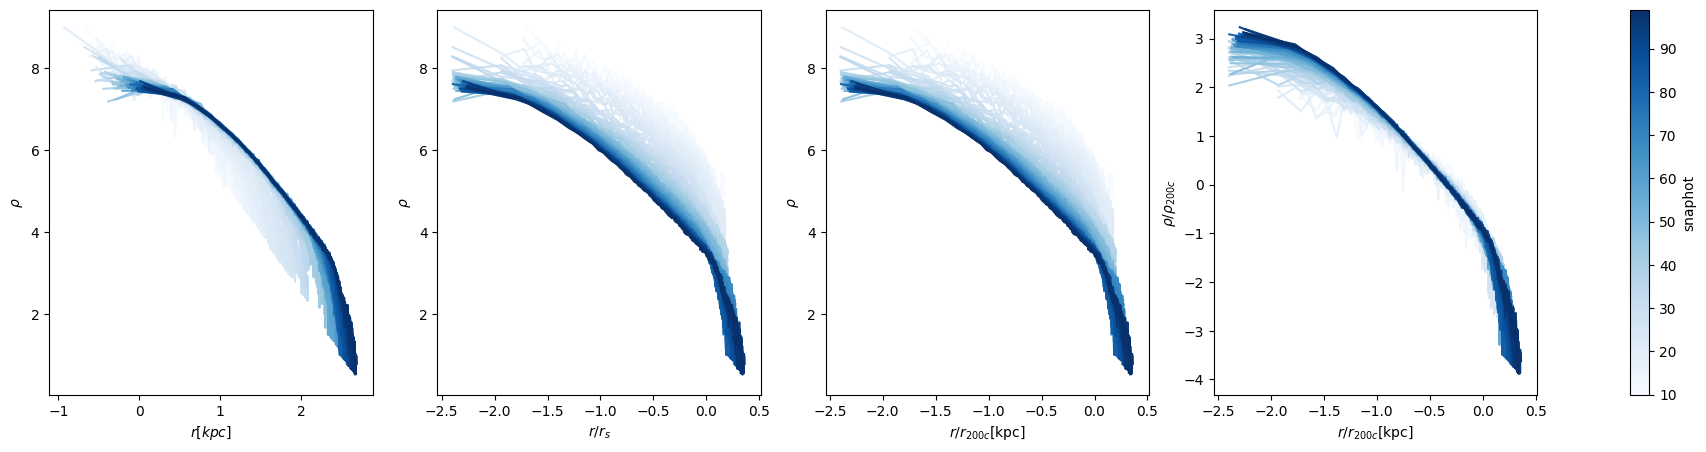

In [5]:
fig, ax = plt.subplots(1,4,figsize=(24,5))
init_snap = 10
snaps = range(init_snap, 100)
norm = mpl.colors.Normalize(vmin=min(snaps), vmax=max(snaps))
cmap = plt.cm.Blues
for snap in snaps:
    r, rho = read_density_profile(density_filename, snap=snap)
    j = np.searchsorted(halo_params['snap'], snap)
    ax[3].plot(np.log10(r/r200c[j]), np.log10(rho/rho200c[j]), color=cmap(norm(snap)), ls='-')
    ax[2].plot(np.log10(r/r200c[j]), np.log10(rho), color=cmap(norm(snap)), ls='-')
    ax[1].plot(np.log10(r/r200c[j]), np.log10(rho), color=cmap(norm(snap)), ls='-')
    ax[0].plot(np.log10(r), np.log10(rho), color=cmap(norm(snap)), ls='-')


sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='snaphot')

ax[0].set_xlabel('$r[kpc]$')
ax[1].set_xlabel('$r/r_s$')
ax[2].set_xlabel('$r/r_{200c}$[kpc]')
ax[3].set_xlabel('$r/r_{200c}$[kpc]')

ax[0].set_ylabel(r'$\rho$')
ax[1].set_ylabel(r'$\rho$')
ax[2].set_ylabel(r'$\rho$')
ax[3].set_ylabel(r'$\rho/\rho_{200c}$')
plt.savefig('../temp_figures/halo_21537_normalized_density_profile.png', bbox_inches='tight')

In [9]:
def diemer22_profile(x, alpha=0.15, beta=4.0, rs=0.2, rt=1.0):
    """
    Compute the dimensionless density profile from the Diemer (2022) model.

    This function evaluates the exponential density profile described in 
    Diemer (2022), which models the outer structure of dark matter halos.

    Parameters
    ----------
    x : array_like
        Dimensionless radius, typically defined as `r / r_200m` or another
        normalized radial coordinate. Must be positive.
    alpha : float, optional
        Inner slope transition parameter. Controls the curvature of the 
        inner profile. Typical values are around 0.15.
    beta : float, optional
        Outer steepening parameter. Controls how sharply the profile 
        steepens beyond the truncation radius. Default is 4.0.
    rs : float, optional
        Scale radius of the halo, defining the transition between the 
        inner and outer regions. Default is 0.2.
    rt : float, optional
        Truncation radius, typically associated with the splashback radius.
        Default is 1.0.

    Returns
    -------
    ndarray
        The dimensionless density profile evaluated at each radius `x`.

    Notes
    -----
    The function implements:

    .. math::
        S = -\\frac{2}{\\alpha}[(x/r_s)^\\alpha - 1] - 
            \\frac{1}{\\beta}[(x/r_t)^\\beta - (r_s/r_t)^\\beta]

        \\rho(x) \\propto e^{S}

    References
    ----------
    Diemer, B. (2023), MNRAS 519, 3292–3311
    """
    S = (
        -2.0 / alpha * ((x / rs) ** alpha - 1.0)
        - (1.0 / beta) * ((x / rt) ** beta - (rs / rt) ** beta)
    )
    return np.exp(S)

In [31]:
def fit_diemer22_profile(x, y):
    """
    Fit the Diemer (2022) profile to data in log-space.

    Fitting in log-space equalizes weighting across the many orders of magnitude
    spanned by a density profile, avoiding domination by the high-density inner
    points that occurs with linear least-squares. An overall amplitude `A` is
    included as a free parameter because the Diemer model is normalized to
    rho=1 at r=rs, while the data rho/rho200c can be O(1e3).

    Parameters
    ----------
    x : array-like
        Dimensionless radius (e.g., r/r200c).
    y : array-like
        Measured (dimensionless) density profile at x.

    Returns
    -------
    popt : ndarray
        Best-fit parameters: A, alpha, beta, rs, rt.
    pcov : 2d ndarray
        Covariance matrix of the fit.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # Mask out non-positive values (would produce -inf / NaN in log)
    mask = (y > 0) & np.isfinite(y)
    x, y = x[mask], y[mask]

    log_y = np.log(y)

    def log_model(x, A, alpha, beta, rs, rt):
        return np.log(A) + np.log(diemer22_profile(x, alpha=alpha, beta=beta, rs=rs, rt=rt))

    # Estimate initial amplitude from data at the scale radius guess
    A0 = np.interp(0.2, x, y)  # rho at rs ~ 0.2
    p0  = [A0,  0.2, 4.0, 0.2, 1.0]
    bounds = (
        [A0 * 1e-3, 0.1, 2.0, 0.05, 0.5],
        [A0 * 1e3,  0.35, 8.0, 2.0,  3.0],
    )
    popt, pcov = curve_fit(log_model, x, log_y, p0=p0, bounds=bounds, maxfev=100000)
    return popt, pcov


In [32]:
fit_halo, fit_cov = fit_diemer22_profile(r/r200c[-1], (rho/rho200c[-1]))
A_fit, alpha_fit, beta_fit, rs_fit, rt_fit = fit_halo
profile_fit = A_fit * diemer22_profile(r/r200c[-1], alpha=alpha_fit, beta=beta_fit, rs=rs_fit, rt=rt_fit)
print(f"A={A_fit:.3g}, alpha={alpha_fit:.3f}, beta={beta_fit:.3f}, rs={rs_fit:.3f}, rt={rt_fit:.3f}")


A=22, alpha=0.190, beta=3.346, rs=0.123, rt=1.026


/tmp/ipykernel_650179/4016749217.py:8: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.log10(r/r200c[j]), np.log10(rho/rho200c[j]), color=cmap(norm(snap)), ls='-')


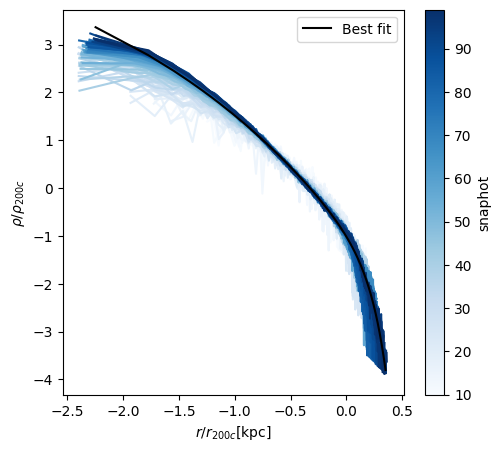

In [33]:
fig, ax = plt.subplots(figsize=(5.5,5))
snaps = range(10, 100)
norm = mpl.colors.Normalize(vmin=min(snaps), vmax=max(snaps))
cmap = plt.cm.Blues
for snap in snaps:
    r, rho = read_density_profile(density_filename, snap=snap)
    j = np.searchsorted(halo_params['snap'], snap)
    ax.plot(np.log10(r/r200c[j]), np.log10(rho/rho200c[j]), color=cmap(norm(snap)), ls='-')


plt.plot(np.log10(r/r200c[-1]), np.log10(profile_fit), c='k', label='Best fit')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label='snaphot')

ax.legend()
ax.set_xlabel('$r/r_{200c}$[kpc]')
ax.set_ylabel(r'$\rho/\rho_{200c}$')
plt.savefig('../temp_figures/halo_21537_normalized_fit_density_profile.png', bbox_inches='tight')

In [19]:
r_upsample = np.linspace(r[0]/r200c[-1], r[-1]/r200c[-1], 2000)
profile_fit_upsample = A_fit * diemer22_profile(r_upsample, alpha=alpha_fit, beta=beta_fit, rs=rs_fit, rt=rt_fit)


In [21]:
halo = 21537
header = (
    f"Diemer (2022) best-fit profile for halo 21537\n"
    f"r200c[-1] = {r200c[-1]:.4f} kpc\n"
    f"Best-fit parameters: A={A_fit:.6g}, alpha={alpha_fit:.6f}, beta={beta_fit:.6f}, rs={rs_fit:.6f}, rt={rt_fit:.6f}\n"
    f"Columns: r/r200c, rho/rho200c (profile_fit)"
)
#np.savetxt("../data/density_profile_fit_halo_{}.txt".format(halo), np.array([r_upsample, profile_fit_upsample]), header=header)

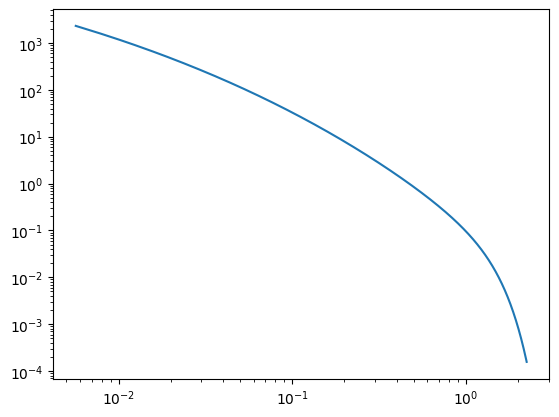

In [53]:
plt.loglog(r_upsample, profile_fit_upsample)

In [54]:
print(r200c[-1], rho200c[-1])

216.35577570980266 25463.891824026778
